# Project 2 SIR: Epidemiological Model
Author: Santiago Sanchez Covarrubias
Date: April 5th

Project description:
Develop an SIR 2D CA class with configurable initial state and parameters to control transmission and recovery
rates. Your model can be purely deterministic or stochastic.

objectives:
- to develop a Cellular Automata SIR model of disease epidemiology
- to experiment with intervention policies, like masking or social distancing to examine their
effect

****

**Common terminology:**
- S = susceptibility
- I = infected
- R = removed (deceased)
- N = population

**Parameters:**

Just three states: susceptible, Infected, removed or deceased
- By given initial grid and given probability x a cell will be susceptible to be infected.
- By given probability x the cell will be inmune.
- By given probability x a cell can is initialze as infected


**Transitions of SIR model:**
- By given probability x (low), an infected cell will died no state recovered
- By given probability x an infected cell will recovered from infection with immunity
- If a cell has one or more cell infected, will have different probabilites of getting infected, 20% for one cell, 40% for two cell, 60% for 3 cell and 80% for 4 cell only counting the the cardinal neighbors



In [6]:
%matplotlib inline

import time
from pprint import pprint

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import animation
from scipy.signal import correlate2d
assert callable(np.array)

# Configure matplotlib's animation library to work in the browser.
matplotlib.rc('animation', html='jshtml')

# Helper functions

In [2]:
# Qualitative colour map with value 0 set to white
tab20_mod = matplotlib.colormaps['tab20']
tab20_mod.colors = ((1,1,1,1), *tab20_mod.colors[1:])

def plot_2d_array(array, axes=None, title='', cmap=tab20_mod, **options):
    """
    Plot the 2D array as an image on the given axes  1's will be dark blue, 0's will be light blue.

    :param axes: the axes to plot on, or None to use the `plt.gca()` (current axes)
    :param options: keyword arguments passed directly to `plt.imshow()`
           see https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html
    """
    axes = axes or plt.gca()  # If not axes are provided, draw on current axes
    axes.set_title(title)
    # Turn off axes labels and tick marks
    axes.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False ,
                     labelbottom=False, labeltop=False, labelleft=False, labelright=False,)
    # Defaults for displaying a "matrix" with hard-pixel boundaries and (0,0) at top-left
    options = {**dict(interpolation='nearest', origin='upper'), **options}
    axes.imshow(array, cmap=cmap, **options)

In [3]:
class Animation2D:
    """
      Animates any 2D model with a step() method and a draw() method, using matplotlib
      model.step() should take no parameters - just step the model forward one step.
      model.draw() should take 2 parameters, the matpltolib axes to draw on and an integer step number

      See https://www.allendowney.com/blog/2019/07/25/matplotlib-animation-in-jupyter/
          for a discussion of the pros and cons of various animation techniques in jupyter notebooks
    """

    def __init__(self, model, frames=50, steps_per_frame=1, figsize=(8, 8)):
        """
        :param model: the simulation object to animate, with step() and draw(axes, step) methods
        :param frames: number of animation frames to generate
        """
        self.model = model
        self.frames = frames
        self.steps_per_frame = steps_per_frame
        self.fig, self.ax = plt.subplots(figsize=figsize)

    def animation_step(self, step):
        """ Step the model forward and draw the plot """
        if step > 0:
            for _ in range(self.steps_per_frame):
                self.model.step()
        self.model.draw(self.ax, step=step * self.steps_per_frame)

    def show(self):
        """ return the matplotlib animation object, ready for display """
        anim = animation.FuncAnimation(self.fig, self.animation_step, frames=self.frames)
        plt.close()  # this ensures the last frame is not shown as a separate plot
        return anim

    def animate(self, interval=None):
        """ Animate the model simulation directly in the notebook display block """
        from IPython.display import clear_output
        try:
            for i in range(self.frames):
                clear_output(wait=True)  # clear the IPython display
                self.ax.clear()  # clear old image from the axes (fixes a performance issue)
                plt.figure(self.fig)  # add the figure back to pyplot ** sigh **
                self.animation_step(i)
                plt.show()  # show the current animation frame (pyplot then closes and throws away figure ** sigh **)
                if interval:
                    time.sleep(interval)
        except KeyboardInterrupt:
            pass

# Class SIR model
- **transitions**
- By given probability x (low), an infected cell will died no state recovered
- By given probability x an infected cell will recovered from infection with immunity or going back to be susceptible to the disease
- If a cell has one or more cell infected, will have different probabilites of getting infected, 20% for one cell, 40% for two cell, 60% for 3 cell and 80% for 4 cell only counting the the cardinal neighbors

- **Common terminology:**
  - S = susceptibility
  - I = infected
  - R = removed (deceased)
  - N = population

- **Parameters:**

Just three states: susceptible, Infected, removed or deceased
- By given initial grid and given probability x a cell will be susceptible to be infected.
- By given probability x the cell will be inmune.
- By given probability x a cell can is initialze as infected









In [89]:
class SIR():
  '''SIR class, model to replicate an epidemiology case by given different parameters'''

   # Define names for the 3 possible cell states
  INFECTED = 5
  SUSCEPTIBLE = 2
  DECEASED = 0
  IMMUNE = 1

  # Define a colour map that maps each cell state to an intuitive colour.
  cmap = [(0.0, 0.0, 0.0)] * 6 # initialize a list of tuple of size number of states
  cmap[IMMUNE] = (1.0, 1.0, 1.0)  # white color
  cmap[DECEASED] = (0.0, 0.0, 0.0)  # black
  cmap[INFECTED] = (1.0, 0.0, 0.0)  # red
  cmap[SUSCEPTIBLE] = (1.0, 1.0, 0.0)  # yellow
  sir_model_color_map = matplotlib.colors.ListedColormap(cmap)

  # define a sensible correlation kernel to detect cardinal neighbourhood is infected
  kernel = np.array([[0, 1, 0], [1, 0, 1], [0, 1, 0]])

  def __init__(self, n, infection_rate = 0.3, immunity_rate = 0.09, mortality_rate = 0.09, recovery_rate = 0.3 ):
    '''Initialzie the model

    parameters:
    n: number of rows
    infection_rate: probability x of number of infected people given the initial grid
    immunity_rate: probability x of number of immune people given the initial grid
    mortality_rate: probability x of a cell to die
    recovery_rate: probability x of a cell to recover from an infection


    '''

    #initilaize values
    self.infection_rate = infection_rate
    self.immunity_rate = immunity_rate
    self.mortality_rate = mortality_rate
    self.recovery_rate = recovery_rate
    self.susceptibility_rate =  1 - self.infection_rate

    self.state = np.random.choice([self.SUSCEPTIBLE, self.INFECTED], (n,n), p=[self.susceptibility_rate, self.infection_rate] )

    '''Things to develop:'''

    #def step function to exectue each one of the transitions
  def step(self) -> np.array:
    '''Executes the transitions steps and updates self.state '''

    infected_mask = self.state == self.INFECTED # mask at giveninfect people
    susceptible_mask = self.state == self.SUSCEPTIBLE

    self.infected_recovered(infected_mask) # change previous infected cells to susceptible(recovered) or immune

    infected_mask = self.state == self.INFECTED # get a new infected mask to distinguish between dead cells and infected cells
    self.infected_dead(infected_mask) #change previous infected cells to deceased by probability mortality_rate

    self.neighbourhood_susceptible_infected(susceptible_mask) # change previous susceptible cells to infected cells by probability infection_rate
    self.susceptible_infected()


  #def infected_to_dead function
  def infected_dead(self, mask: np.array) -> np.array:
    '''Function that changes infected people to deceased '''

    self.state[mask] = np.random.choice([self.INFECTED, self.DECEASED], size=mask.sum(), p=[1-self.mortality_rate, self.mortality_rate])

  #def infected_to_recovered function
  def infected_recovered(self, mask: np.array) -> np.array:
    '''Function to transition from infected people to recovered or immune '''

    self.state[mask] = np.random.choice([self.INFECTED, self.SUSCEPTIBLE, self.IMMUNE], size=mask.sum(), p=[1 - (self.recovery_rate + self.immunity_rate), self.recovery_rate, self.immunity_rate])

  #def susceptible_to_infected function
  def neighbourhood_susceptible_infected(self, mask_susceptible: np.array) -> np.array:
    '''Function to transition from susceptible cell to an infected cell '''

    #loop through each cell giving the value 1 to cell 5 and all other ones are set to 0
    infected_neighbourhood = correlate2d((self.state == self.INFECTED).astype(int), self.kernel, mode='same', boundary='wrap')

    infected_neighbourhood = infected_neighbourhood.astype(float)

    infected_neighbourhood *= 0.2 # update value by probabilities 0.2, 0.4, 0.6, 0.8
    random_mask = np.random.random(size= self.state.shape) #create array of random values

    mask = (mask_susceptible) & (infected_neighbourhood >= random_mask) # check if cell is susceptible and if the proability at given cell is grater than random value


    self.state[mask] = self.INFECTED #update values

  def susceptible_infected(self) -> np.array:
    '''By given probability infenction_rate a susceptible cell may get sick even if no nearby by infeected cells '''

    #initialize masks
    mask_susceptible = self.state == self.SUSCEPTIBLE
    random_mask = np.random.random(size=self.state.shape)

    #create mask to affect self.state
    mask = (mask_susceptible) & (random_mask <= self.infection_rate)

    self.state[mask] = self.INFECTED

  '''
  communicative data functions
  '''

  # infected cells data
  def number_infected_cells(self) -> int:
    '''Returns number of cells infected '''

    return (self.state == self.INFECTED).sum()

  def proportion_infected_cells(self) -> float:
    '''Returns proportions of infected cells  in the array'''
    return  self.number_infected_cells() / self.state.size

  #immune cells data

  def number_immune_cells(self) -> int:
    '''Returns number of immune cells '''
    return (self.state == self.IMMUNE).sum()

  def proportion_immune_cells(self) -> float:
    '''Returns the proportion of immune cells in the array '''
    return self.number_immune_cells() / self.state.size

  #susceptible data

  def number_susceptible_cells(self) -> int:
    '''Retunrs nummber of susceptible cells '''

    return (self.state == self.SUSCEPTIBLE).sum()

  def proportion_susceptible_cells(self) -> float:
    '''returns the proportion of susceptible cells '''

    return self.number_susceptible_cells() / self.state.size

  # dead cells data

  def number_dead_cells(self) -> int:
    '''returns number of dead cells '''

    return (self.state == self.DECEASED).sum()

  def proportion_dead_cells_data(self) -> float:
    '''Returns the proportion of dead cells '''

    return self.number_dead_cells() / self.state.size

  def draw(self, axes=None, step=''):
        """Draws the CA cells using the forest colour map so values are coloured intuitively."""
        axes = axes or plt.gca()
        title = f'Time:{step} infected: {round(self.proportion_infected_cells() * 100, 2)}%'
        plot_2d_array(self.state, axes=axes, title=title,
                      cmap=self.sir_model_color_map, vmin=0, vmax=len(self.sir_model_color_map.colors))



In [73]:
#unit testing
covid = SIR(5, infection_rate=0.5)
print(covid.state)
print(covid.proportion_infected_cells())
covid.step()
print(covid.state)
print(covid.proportion_infected_cells())


[[5 5 2 5 5]
 [5 5 5 5 2]
 [2 2 5 5 5]
 [5 5 5 5 5]
 [5 2 5 5 2]]
0.76
[[5 5 2 2 5]
 [5 5 5 0 5]
 [5 2 5 5 5]
 [5 5 5 5 5]
 [5 5 5 5 5]]
0.84


# Animation
the class/model will run under certain number steps will displaying how does it look like
**color reference**

  - immune: white
  - deceased: black
  - infected: red
  - susceptible: yellow

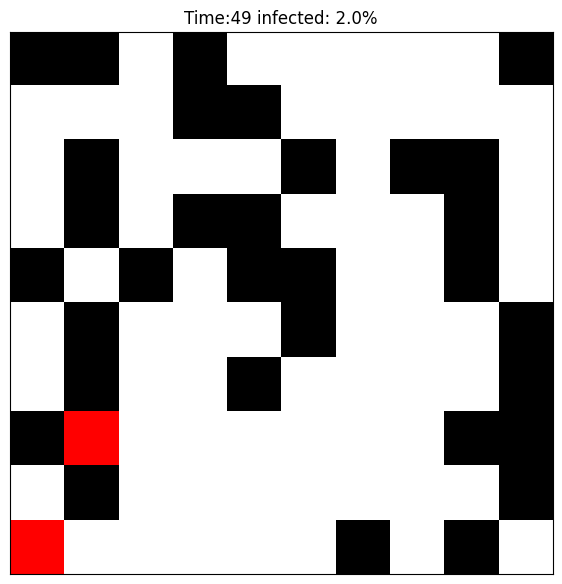

In [88]:
#Animation display

covid = SIR(10)

animation = Animation2D(covid, frames=50, steps_per_frame=1, figsize=(7,8) )
animation.animate()